In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

matches = pd.read_csv("C:\\Users\\HP\\OneDrive\\Desktop\\ipl-analytics\\data\\matches.csv")
deliveries = pd.read_csv("C:\\Users\\HP\\OneDrive\\Desktop\\ipl-analytics\\data\\deliveries.csv")

Which team won the most matches?

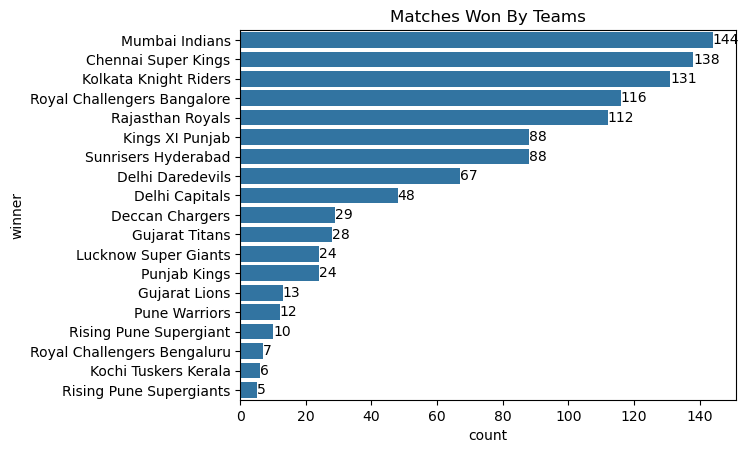

<Figure size 640x480 with 0 Axes>

In [36]:
ax = sns.countplot(
    y="winner",
    data=matches,
    order=matches["winner"].value_counts().index,
    
)

# Annotate each bar with the count
for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.0f}",  # The count value
        (p.get_width(), p.get_y() + p.get_height() / 2),  # Position at the end of the bar
        ha='left',  # Horizontal alignment
        va='center'   # Vertical alignment
    )


plt.title("Matches Won By Teams")
plt.show()
plt.tight_layout()

Who are the top 10 run scorers?

In [37]:
top_batsmen = (
    deliveries
    .groupby("batter")["batsman_runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_batsmen)

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


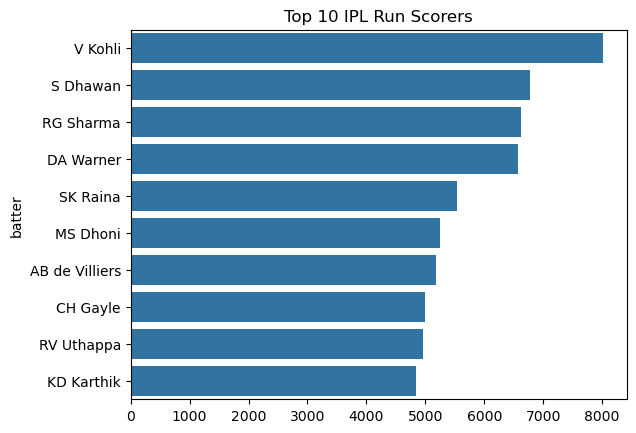

In [38]:
ax = sns.barplot(
    x=top_batsmen.values,
    y=top_batsmen.index
)


plt.title("Top 10 IPL Run Scorers")
plt.show()

Who took the most wickets?

In [39]:
valid_wickets = deliveries[
    (deliveries["is_wicket"] == 1)
    &
    (~deliveries["dismissal_kind"].isin([
        "run out",
        "retired hurt",
        "obstructing the field"
    ]))
]

top_bowlers = (
    valid_wickets
    .groupby("bowler")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(top_bowlers)

bowler
YS Chahal     205
PP Chawla     192
DJ Bravo      183
B Kumar       181
SP Narine     180
R Ashwin      180
A Mishra      174
SL Malinga    170
JJ Bumrah     168
RA Jadeja     160
dtype: int64


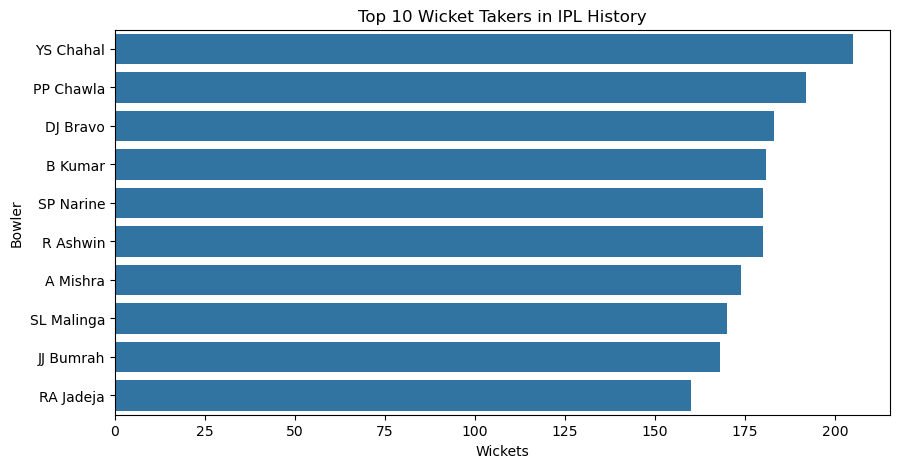

In [40]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_bowlers.values,
    y=top_bowlers.index
)

plt.title("Top 10 Wicket Takers in IPL History")
plt.xlabel("Wickets")
plt.ylabel("Bowler")
plt.show()

Does winning the toss increase winning chances?

In [41]:
toss_win_match_win = (
    (matches["toss_winner"] == matches["winner"])
    .mean() * 100
)

print(f"{toss_win_match_win:.2f}%")

50.59%


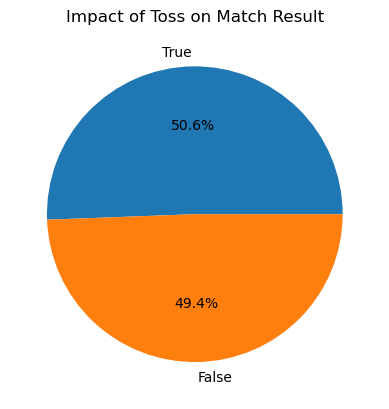

In [42]:
toss_result = (
    matches["toss_winner"] == matches["winner"]
)

toss_result.value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Impact of Toss on Match Result")
plt.ylabel("")
plt.show()

Highest Team Scores in IPL

In [43]:
# Team scores per innings
team_scores = (
    deliveries
    .groupby(["match_id", "batting_team"])["total_runs"]
    .sum()
    .reset_index()
)

# Match details merge
team_scores = team_scores.merge(
    matches[["id", "date", "team1", "team2"]],
    left_on="match_id",
    right_on="id",
    how="left"
)

# Year extract
team_scores["year"] = pd.to_datetime(
    team_scores["date"]
).dt.year

# Opponent nikalna
team_scores["opponent"] = team_scores.apply(
    lambda row: row["team2"]
    if row["batting_team"] == row["team1"]
    else row["team1"],
    axis=1
)

# Final table
top_scores = (
    team_scores[["year", "batting_team", "opponent", "total_runs"]]
    .sort_values("total_runs", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print(top_scores)

   year                 batting_team                     opponent  total_runs
0  2024          Sunrisers Hyderabad  Royal Challengers Bengaluru         287
1  2024          Sunrisers Hyderabad               Mumbai Indians         277
2  2024        Kolkata Knight Riders               Delhi Capitals         272
3  2024          Sunrisers Hyderabad               Delhi Capitals         266
4  2013  Royal Challengers Bangalore                Pune Warriors         263
5  2024                 Punjab Kings        Kolkata Knight Riders         262
6  2024  Royal Challengers Bengaluru          Sunrisers Hyderabad         262
7  2024        Kolkata Knight Riders                 Punjab Kings         261
8  2024               Delhi Capitals               Mumbai Indians         257
9  2023         Lucknow Super Giants                 Punjab Kings         257


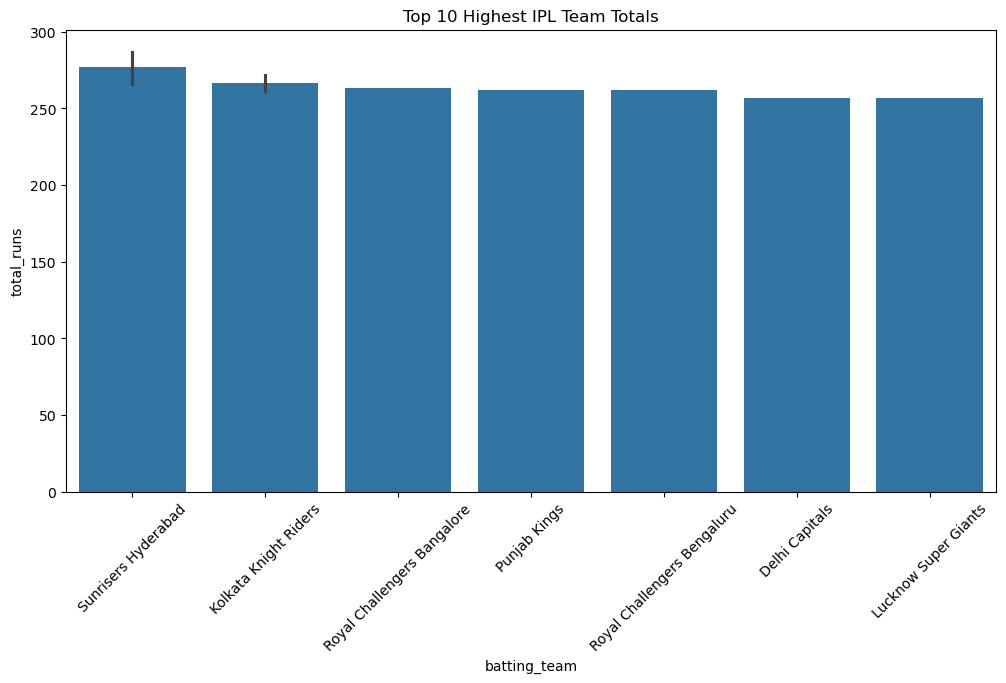

In [44]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_scores,
    x="batting_team",
    y="total_runs"
)

plt.title("Top 10 Highest IPL Team Totals")
plt.xticks(rotation=45)
plt.show()

Top 10 six hitters in IPL history

In [33]:
top_six_hitters = (
    deliveries[deliveries["batsman_runs"] == 6]
    .groupby("batter")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(top_six_hitters)

batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
DA Warner         236
KA Pollard        224
AD Russell        209
SV Samson         206
SK Raina          204
dtype: int64


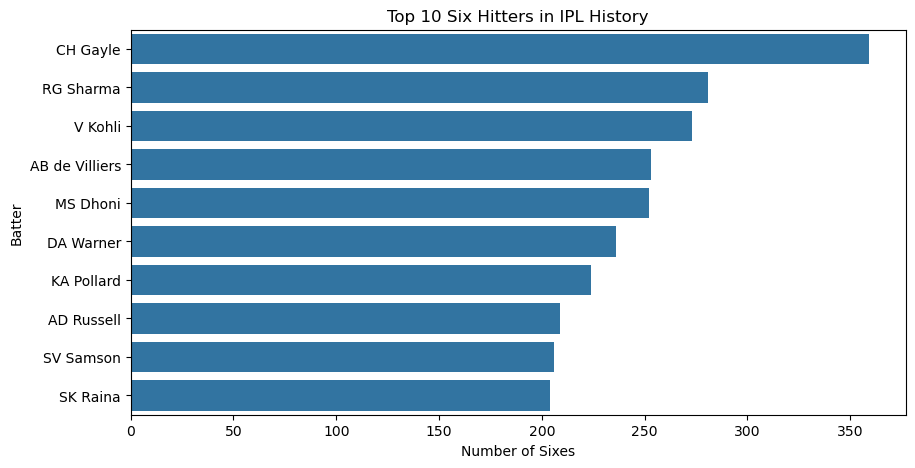

In [34]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_six_hitters.values,
    y=top_six_hitters.index
)

plt.title("Top 10 Six Hitters in IPL History")
plt.xlabel("Number of Sixes")
plt.ylabel("Batter")
plt.show()

Teams with most 200+ scores

In [ ]:
# team name mapping cuz there are changes in name of someteams 
team_name_mapping = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru"
}

team_scores["batting_team"] = (
    team_scores["batting_team"]
    .replace(team_name_mapping)
)

In [62]:
scores_200 = (
    team_scores[team_scores["total_runs"] >= 200]
    .groupby("batting_team", as_index=False)
    .agg(times_scored_200_plus=("total_runs", "count"))
    .sort_values("times_scored_200_plus", ascending=False)
    .reset_index(drop=True)
)

scores_200.index = scores_200.index + 1

print(scores_200)

                   batting_team  times_scored_200_plus
1           Chennai Super Kings                     32
2   Royal Challengers Bengaluru                     30
3         Kolkata Knight Riders                     25
4                Mumbai Indians                     25
5                  Punjab Kings                     25
6              Rajasthan Royals                     21
7           Sunrisers Hyderabad                     21
8                Delhi Capitals                     16
9                Gujarat Titans                      8
10         Lucknow Super Giants                      7
11              Deccan Chargers                      1
12                Gujarat Lions                      1


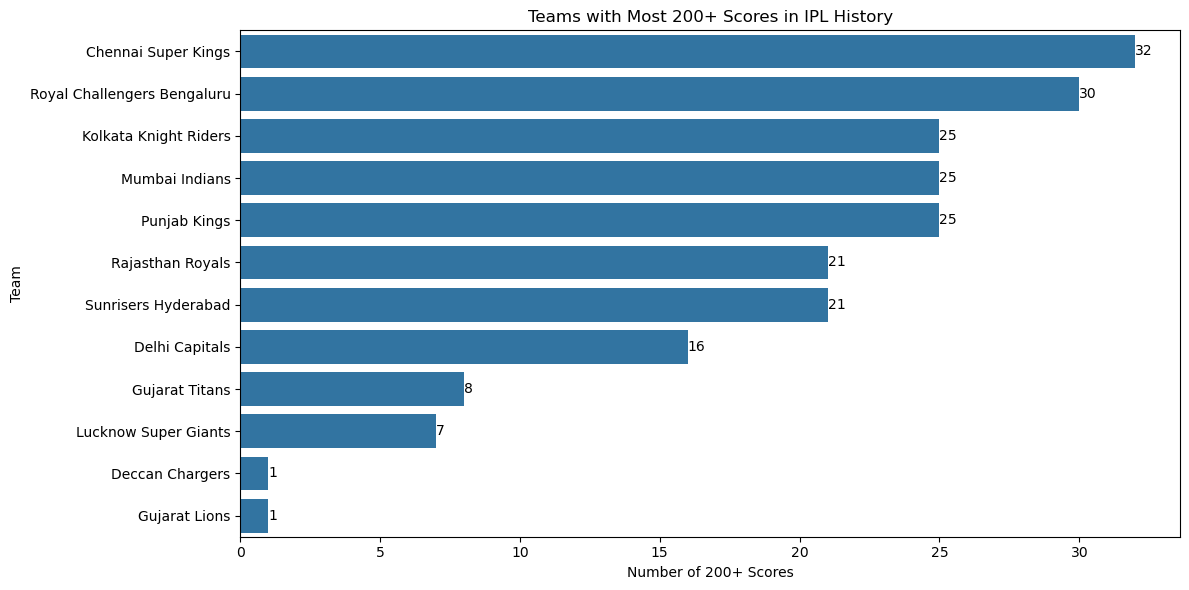

In [64]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=scores_200,
    x="times_scored_200_plus",
    y="batting_team"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Teams with Most 200+ Scores in IPL History")
plt.xlabel("Number of 200+ Scores")
plt.ylabel("Team")

plt.tight_layout()
plt.show()